In [1]:
from datascience import *
import numpy as np

%matplotlib inline
import matplotlib.pyplot as plt
plt.style.use('fivethirtyeight')

In [4]:
t = Table().with_columns(
    'Name', make_array('Lonzo', 'Tony', 'Victor E.'),
    'Species', make_array('cat', 'tiger', 'bulldog'),
    'Age', make_array(5, 2026 - 1952, 8)
)
t

Name,Species,Age
Lonzo,cat,5
Tony,tiger,74
Victor E.,bulldog,8


In [5]:
t.num_rows

3

In [6]:
t.num_columns

3

In [7]:
t.labels

('Name', 'Species', 'Age')

In [10]:
t.select('Name', 2)

Name,Age
Lonzo,5
Tony,74
Victor E.,8


In [11]:
t

Name,Species,Age
Lonzo,cat,5
Tony,tiger,74
Victor E.,bulldog,8


In [12]:
t.drop('Age')

Name,Species
Lonzo,cat
Tony,tiger
Victor E.,bulldog


In [14]:
t.relabeled('Name', 'Nombre')

Nombre,Species,Age
Lonzo,cat,5
Tony,tiger,74
Victor E.,bulldog,8


In [16]:
np.arange(0, 101, 5)

array([  0,   5,  10,  15,  20,  25,  30,  35,  40,  45,  50,  55,  60,
        65,  70,  75,  80,  85,  90,  95, 100])

In [17]:
len(np.arange(0, 101, 5))

21

In [19]:
np.arange(200, -1, -10)

array([200, 190, 180, 170, 160, 150, 140, 130, 120, 110, 100,  90,  80,
        70,  60,  50,  40,  30,  20,  10,   0])

In [20]:
t2 = Table().with_columns(
    'x', np.arange(0, 101, 5),
    'y', np.arange(200, -1, -10)
)
t2

x,y
0,200
5,190
10,180
15,170
20,160
25,150
30,140
35,130
40,120
45,110


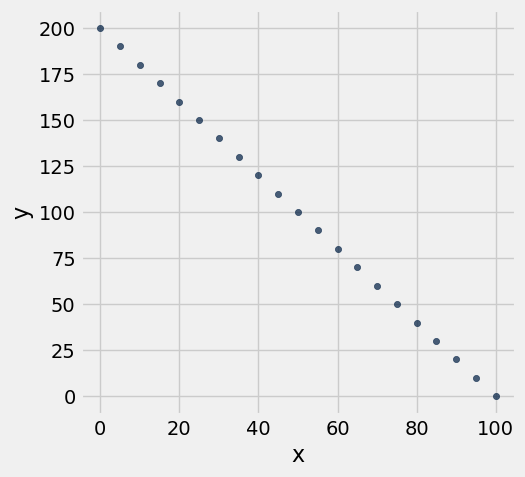

In [21]:
t2.scatter('x', 'y')

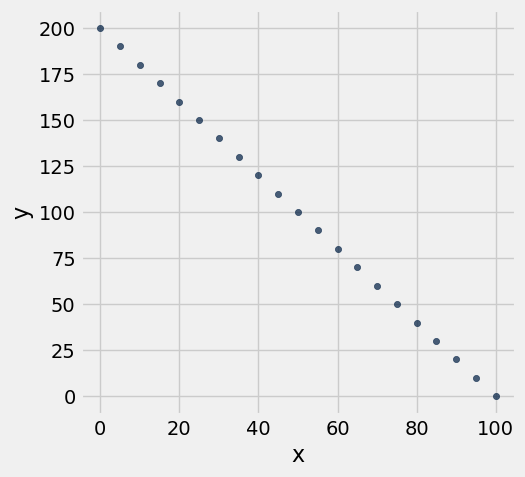

In [22]:
t2.scatter('x')

In [23]:
words = Table.read_table('data/wordle.csv')
words

Words
cigar
rebut
sissy
humph
awake
blush
focal
evade
naval
serve


In [24]:
for i in np.arange(1, 11):
    print(i)

1
2
3
4
5
6
7
8
9
10


In [25]:
for c in 'hello':
    print(c)

h
e
l
l
o


In [26]:
array = make_array()

for c in 'hello':
    array = np.append(array, c)

array

array(['h', 'e', 'l', 'l', 'o'],
      dtype='<U32')

In [27]:
def str_to_array(s):
    array = make_array()

    for c in s:
        array = np.append(array, c)
    
    return array

In [28]:
str_to_array('abc')

array(['a', 'b', 'c'],
      dtype='<U32')

In [30]:
np.append(str_to_array('hello'), str_to_array('world'))

array(['h', 'e', 'l', 'l', 'o', 'w', 'o', 'r', 'l', 'd'],
      dtype='<U32')

In [32]:
words.column('Words')

array(['cigar', 'rebut', 'sissy', ..., 'artsy', 'rural', 'shave'],
      dtype='<U5')

In [34]:
letters_in_every_word = make_array()

for word in words.column(0):
    letters_in_every_word = np.append(letters_in_every_word, str_to_array(word))

letters_in_every_word

array(['c', 'i', 'g', ..., 'a', 'v', 'e'],
      dtype='<U32')

In [35]:
len(letters_in_every_word)

11575

In [37]:
words.take(words.num_rows - 1)

Words
shave


In [39]:
np.count_nonzero(letters_in_every_word == 'h')

389

In [40]:
np.count_nonzero(letters_in_every_word == 'e')

1233

In [42]:
letters = Table().with_column(
    'Letter', str_to_array('abcdefghijklmnopqrstuvwxyz') # make_array('a', 'b', 'c', ...)
)
letters.show()

Letter
a
b
c
d
e
f
g
h
i
j


In [43]:
np.count_nonzero(letters_in_every_word == 'l')

719

In [44]:
def count_character(c):
    return np.count_nonzero(letters_in_every_word == c)

In [45]:
count_character('h')

389

In [46]:
count_character('e')

1233

In [47]:
letters.apply(count_character, 'Letter')

array([ 979,  281,  477,  393, 1233,  230,  311,  389,  671,   27,  210,
        719,  316,  575,  754,  367,   29,  899,  669,  729,  467,  153,
        195,   37,  425,   40])

In [49]:
letters_and_counts = letters.with_column(
    'Count', letters.apply(count_character, 'Letter')
)
letters_and_counts.show()

Letter,Count
a,979
b,281
c,477
d,393
e,1233
f,230
g,311
h,389
i,671
j,27


In [53]:
letters_and_counts.sort('Count', descending=True).show()

Letter,Count
e,1233
a,979
r,899
o,754
t,729
l,719
i,671
s,669
n,575
c,477


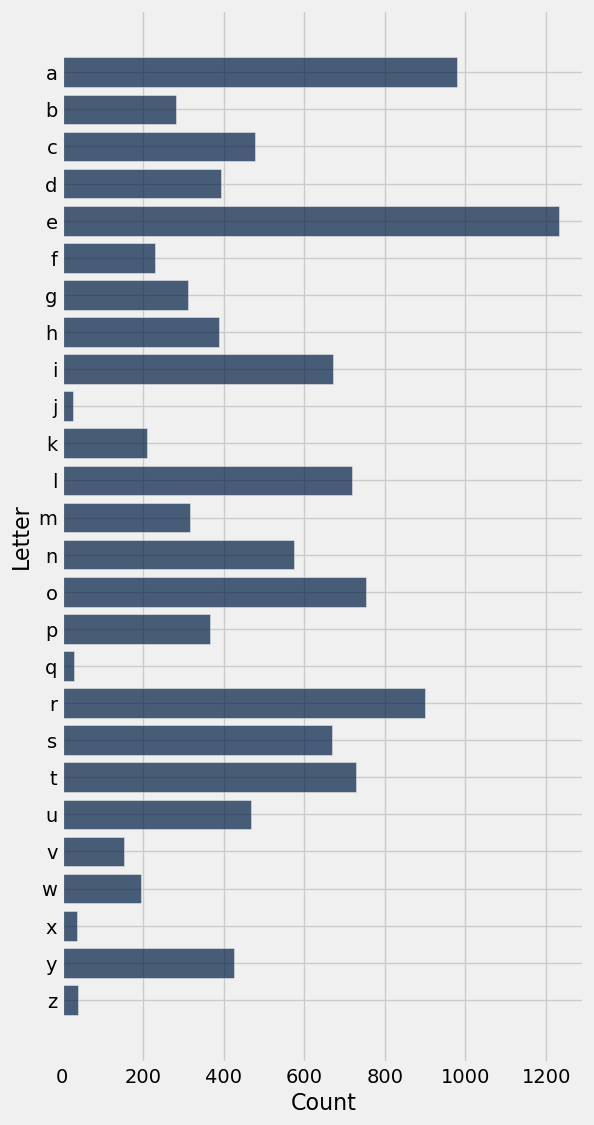

In [54]:
letters_and_counts.barh('Letter')

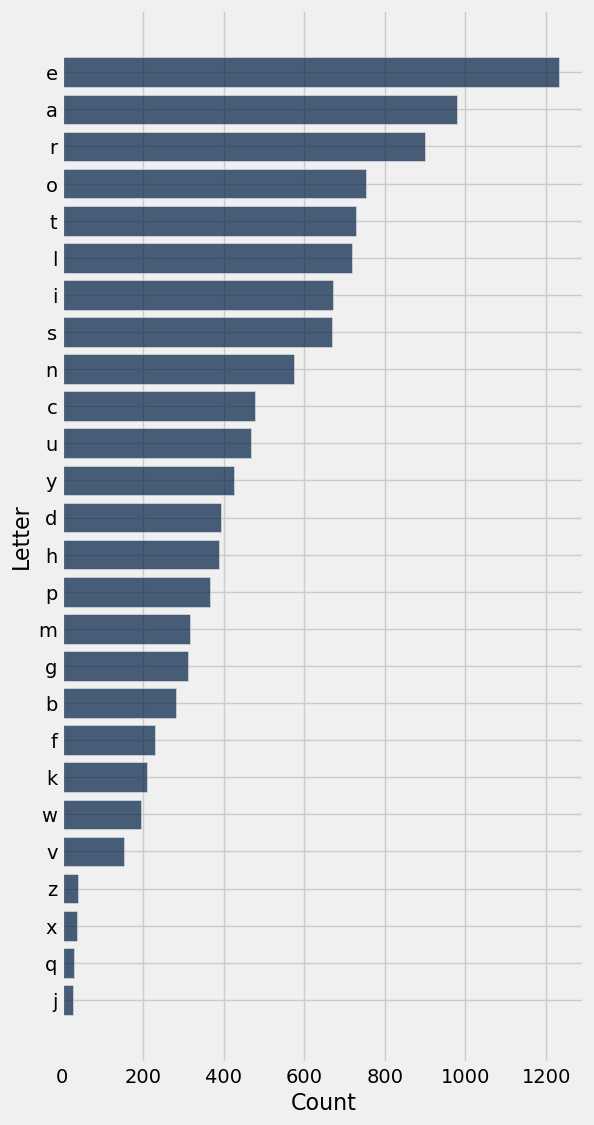

In [56]:
letters_and_counts.sort('Count', descending=True).barh('Letter')

In [58]:
words.where('Words', are.containing('e'))

Words
rebut
awake
evade
serve
heath
model
grade
quiet
bench
abate


In [59]:
words.where('Words', are.containing('e')).where('Words', are.containing('a'))

Words
awake
evade
heath
grade
abate
death
abase
react
paper
adobe


In [60]:
words.where('Words', are.containing('e')).where('Words', are.containing('a')).where('Words', are.containing('r'))

Words
grade
react
paper
repay
crate
yearn
agree
argue
great
break


In [61]:
words.where('Words', are.containing('e')).where('Words', are.containing('a')).where('Words', are.containing('r')).where('Words', are.containing('o'))

Words
adore
arose
opera


In [69]:
array = str_to_array('arose')

letters_and_counts.where('Letter', are.equal_to(array.item(0))).row(0).item(1)

979

In [70]:
score = 0
score = score + letters_and_counts.where('Letter', are.equal_to(array.item(0))).row(0).item(1)
score = score + letters_and_counts.where('Letter', are.equal_to(array.item(1))).row(0).item(1)
score = score + letters_and_counts.where('Letter', are.equal_to(array.item(2))).row(0).item(1)
score = score + letters_and_counts.where('Letter', are.equal_to(array.item(3))).row(0).item(1)
score = score + letters_and_counts.where('Letter', are.equal_to(array.item(4))).row(0).item(1)
score

4534

In [71]:
def get_score(word):
    array = str_to_array(word)

    score = 0
    score = score + letters_and_counts.where('Letter', are.equal_to(array.item(0))).row(0).item(1)
    score = score + letters_and_counts.where('Letter', are.equal_to(array.item(1))).row(0).item(1)
    score = score + letters_and_counts.where('Letter', are.equal_to(array.item(2))).row(0).item(1)
    score = score + letters_and_counts.where('Letter', are.equal_to(array.item(3))).row(0).item(1)
    score = score + letters_and_counts.where('Letter', are.equal_to(array.item(4))).row(0).item(1)
    return score

In [72]:
get_score('arose')

4534

In [73]:
get_score('adore')

4258

In [76]:
words.apply(get_score, 0)

array([3337, 3609, 3103, ..., 3701, 3963, 3423])

In [77]:
words_with_scores = words.with_column(
    'Score', words.apply(get_score, 0)
)
words_with_scores

Words,Score
cigar,3337
rebut,3609
sissy,3103
humph,1928
awake,3596
blush,2525
focal,3159
evade,3991
naval,3405
serve,4187


In [78]:
words_with_scores.sort('Score')

Words,Score
fuzzy,1202
fizzy,1406
jazzy,1511
dizzy,1569
jiffy,1583
jumpy,1602
whiff,1715
puffy,1719
buggy,1795
gummy,1835


In [79]:
words_with_scores.sort('Score', descending=True)

Words,Score
eerie,5269
eater,5073
erase,5013
rarer,4909
elate,4893
tease,4843
easel,4833
lease,4833
tepee,4795
reset,4763


In [84]:
Table().with_column('Letter', str_to_array('eerie')).group('Letter').num_rows

3

In [85]:
Table().with_column('Letter', str_to_array('arose')).group('Letter').num_rows

5

In [86]:
def has_duplicates(word):
    unique_letters = Table().with_column('Letter', str_to_array(word)).group('Letter').num_rows

    if unique_letters == 5:
        return 'no'
    else:
        return 'yes'

In [87]:
has_duplicates('eerie')

'yes'

In [89]:
has_duplicates('arose')

'no'

In [91]:
words_with_scores.apply(has_duplicates, 'Words')

array(['no', 'no', 'yes', ..., 'no', 'yes', 'no'],
      dtype='<U3')

In [92]:
words_scores_duplicates = words_with_scores.with_column(
    'Has Duplicates', words_with_scores.apply(has_duplicates, 'Words')
)
words_scores_duplicates

Words,Score,Has Duplicates
cigar,3337,no
rebut,3609,no
sissy,3103,yes
humph,1928,yes
awake,3596,yes
blush,2525,no
focal,3159,no
evade,3991,yes
naval,3405,yes
serve,4187,yes


In [95]:
words_scores_duplicates.sort('Score', descending=True).where('Has Duplicates', are.equal_to('no'))

Words,Score,Has Duplicates
later,4559,no
alter,4559,no
alert,4559,no
arose,4534,no
irate,4511,no
stare,4509,no
arise,4451,no
raise,4451,no
learn,4405,no
renal,4405,no


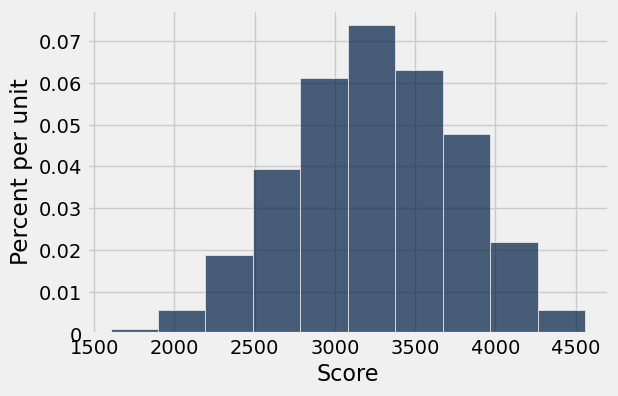

In [96]:
words_scores_duplicates.where('Has Duplicates', 'no').hist('Score')

In [97]:
words_scores_duplicates.where('Has Duplicates', 'no').sort('Score')

Words,Score,Has Duplicates
jumpy,1602,no
jumbo,1845,no
quick,1854,no
buxom,1855,no
mucky,1895,no
funky,1907,no
pudgy,1963,no
dumpy,1968,no
wimpy,1974,no
chump,2016,no


In [98]:
words_scores_duplicates.sort('Score')

Words,Score,Has Duplicates
fuzzy,1202,yes
fizzy,1406,yes
jazzy,1511,yes
dizzy,1569,yes
jiffy,1583,yes
jumpy,1602,no
whiff,1715,yes
puffy,1719,yes
buggy,1795,yes
gummy,1835,yes
